<h1 style = "text-align:center; color: #cceb34; font-size:50px; font-weight:bold">House Price in Nigeria</h1>

##### Importing All Necessary Library

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error


#### Importing the Dataset

In [3]:
df = pd.read_csv('nigeria_houses_data.csv')
df.head()

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,450000000.0
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,800000000.0
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,120000000.0
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,40000000.0
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,75000000.0


#### Data Cleansing

In [4]:
df.shape

(24326, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24326 entries, 0 to 24325
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       24326 non-null  float64
 1   bathrooms      24326 non-null  float64
 2   toilets        24326 non-null  float64
 3   parking_space  24326 non-null  float64
 4   title          24326 non-null  object 
 5   town           24326 non-null  object 
 6   state          24326 non-null  object 
 7   price          24326 non-null  float64
dtypes: float64(5), object(3)
memory usage: 1.5+ MB


In [6]:
df.isna().sum()

bedrooms         0
bathrooms        0
toilets          0
parking_space    0
title            0
town             0
state            0
price            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(10438)

In [8]:
# Droping the duplicates
df.drop_duplicates(inplace=True)

In [9]:
df['title'].unique()

array(['Detached Duplex', 'Terraced Duplexes', 'Semi Detached Duplex',
       'Detached Bungalow', 'Block of Flats', 'Semi Detached Bungalow',
       'Terraced Bungalow'], dtype=object)

In [10]:
df['state'].unique()

array(['Abuja', 'Lagos', 'Edo', 'Ogun', 'Oyo', 'Imo', 'Anambara',
       'Rivers', 'Enugu', 'Kaduna', 'Kwara', 'Nasarawa', 'Abia', 'Delta',
       'Akwa Ibom', 'Osun', 'Ekiti', 'Cross River', 'Kogi', 'Plateau',
       'Kano', 'Katsina', 'Bayelsa', 'Borno', 'Niger'], dtype=object)

In [11]:
# Checking if the towns matches with the states
for state in df['state'].unique():
    print(state, ':', df[df['state'] == state]['town'].unique())
    print('======'*20)

Abuja : ['Mabushi' 'Katampe' 'Lokogoma District' 'Kaura' 'Galadimawa' 'Gwarinpa'
 'Lugbe District' 'Jahi' 'Orozo' 'Guzape District' 'Idu Industrial'
 'Utako' 'Kuje' 'Life Camp' 'Dape' 'Gaduwa' 'Dakwo' 'Asokoro District'
 'Wuye' 'Kubwa' 'Apo' 'Wuse 2' 'Durumi' 'Maitama District' 'Karsana'
 'Wuse' 'Kurudu' 'Karmo' 'Gudu' 'Kukwaba' 'Mbora (Nbora)' 'Jabi' 'Garki'
 'Karshi' 'Kado' 'Nyanya' 'Kyami' 'Dutse' 'Karu' 'Kafe' 'Dakibiyu' 'Bwari'
 'Kagini' 'Mpape' 'Gwagwalada' 'Diplomatic Zones' 'Kabusa' 'Dei-Dei'
 'Duboyi' 'Jikwoyi' 'Central Business District' 'Wumba' 'Mararaba']
Lagos : ['Lekki' 'Ajah' 'Epe' 'Victoria Island (VI)' 'Ikeja' 'Ikoyi' 'Magodo'
 'Ibeju Lekki' 'Yaba' 'Ifako-Ijaiye' 'Agege' 'Ikorodu' 'Isheri North'
 'Isheri' 'Ipaja' 'Mushin' 'Ejigbo' 'Isolo' 'Ojodu' 'Alimosho' 'Shomolu'
 'Ogudu' 'Surulere' 'Ayobo' 'Ikotun' 'Maryland' 'Gbagada' 'Idimu' 'Ojo'
 'Kosofe' 'Ilupeju' 'Ketu' 'Ojota' 'Oshodi' 'Amuwo Odofin' 'Ijede'
 'Agbara-Igbesa' 'Ijaiye' 'Apapa' 'Lagos Island' 'Badagry' 'Oke-Od

From the above I found out that towns in Anambara state are not correct.
We need the drop the Anambara state.

In [12]:
df = df[df['state']!='Anambara']

Checking and dropping states with records lesser than 20

In [13]:
df['state'].value_counts()

state
Lagos          8571
Abuja          3118
Ogun            579
Oyo             435
Rivers          422
Imo             229
Enugu           121
Edo              98
Delta            62
Akwa Ibom        25
Kaduna           23
Osun             12
Abia              9
Nasarawa          9
Kwara             9
Ekiti             9
Kogi              4
Cross River       2
Plateau           2
Kano              2
Katsina           2
Bayelsa           2
Borno             1
Niger             1
Name: count, dtype: int64

In [14]:
town_count = df['state'].value_counts()
lesser_town_list = town_count[town_count < 20].index
lesser_town_list

df = df[~df['state'].isin(lesser_town_list)]
df

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,4.500000e+08
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,8.000000e+08
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,1.200000e+08
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,4.000000e+07
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,7.500000e+07
...,...,...,...,...,...,...,...,...
24319,8.0,8.0,9.0,4.0,Detached Duplex,Guzape District,Abuja,1.000000e+09
24320,3.0,4.0,4.0,5.0,Detached Duplex,Lekki,Lagos,8.000000e+07
24321,2.0,2.0,2.0,4.0,Block of Flats,Kabusa,Abuja,1.500000e+07
24322,4.0,5.0,5.0,4.0,Block of Flats,Ado-Odo/Ota,Ogun,2.500000e+07


In [15]:
df['price'] = df['price'].astype('int')
df

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,450000000
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,800000000
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,120000000
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,40000000
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,75000000
...,...,...,...,...,...,...,...,...
24319,8.0,8.0,9.0,4.0,Detached Duplex,Guzape District,Abuja,1000000000
24320,3.0,4.0,4.0,5.0,Detached Duplex,Lekki,Lagos,80000000
24321,2.0,2.0,2.0,4.0,Block of Flats,Kabusa,Abuja,15000000
24322,4.0,5.0,5.0,4.0,Block of Flats,Ado-Odo/Ota,Ogun,25000000


### EDA

In [16]:
df.describe(include = 'all')

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
count,13683.000000,13683.000000,13683.000000,13683.000000,13683,13683,13683,1.368300e+04
unique,NaN,NaN,NaN,NaN,7,165,11,NaN
top,NaN,NaN,NaN,NaN,Detached Duplex,Lekki,Lagos,NaN
freq,NaN,NaN,NaN,NaN,6413,3392,8571,NaN
mean,4.195133,4.523569,5.005920,4.077615,NaN,NaN,NaN,4.050146e+08
std,1.313602,1.358950,1.423088,1.642727,NaN,NaN,NaN,1.626974e+10
min,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,9.000000e+04
25%,3.000000,4.000000,4.000000,3.000000,NaN,NaN,NaN,3.800000e+07
50%,4.000000,5.000000,5.000000,4.000000,NaN,NaN,NaN,7.500000e+07
75%,5.000000,5.000000,6.000000,5.000000,NaN,NaN,NaN,1.600000e+08


<h3 style = "text-align:center; font-weight:bold;">Findings</h2>

*From the quick analysis I found out that:*
1. There are 13683 records.
2. The maximum numbers of bedrooms, bathrooms, toilets is 9.
3. In this dataset after data cleansing, we have 11 states and 165 towns. Lagos state is the state
with the higest record and Lekki the town with the higest record.
4. The Hightest cost of housing is the 1.8 trillion naira while the lowest cost is 90 thousand naira.


#### Further Analysis

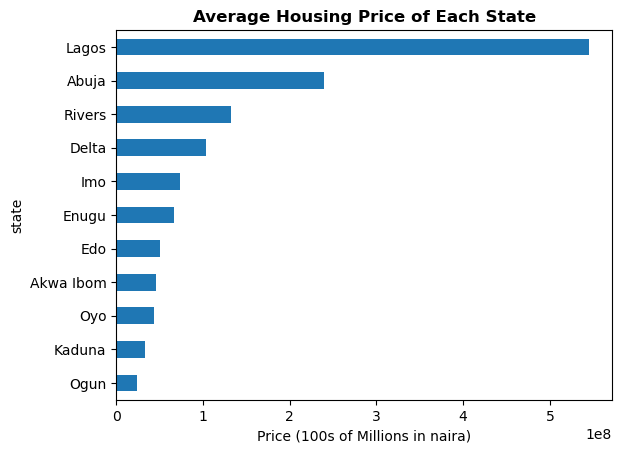

In [17]:
df.groupby('state')['price'].mean().sort_values(ascending=True).plot(kind='barh')
plt.title('Average Housing Price of Each State', weight = 'bold')
plt.xlabel('Price (100s of Millions in naira)')
plt.show()

Text(0.5, 1.0, 'Top 10 Most Expensive Towns in Nigeria by Avg Housing Price')

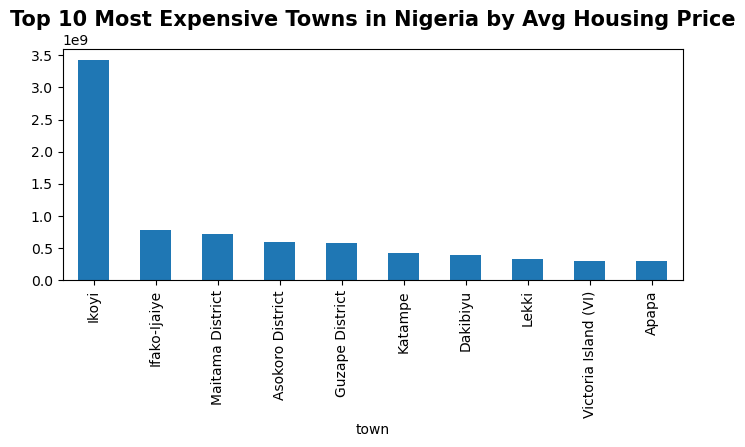

In [18]:
plt.figure(figsize=(8, 3))
df.groupby('town')['price'].mean().astype(int).sort_values(ascending=False).head(10)\
.plot(kind = 'bar')
plt.title('Top 10 Most Expensive Towns in Nigeria by Avg Housing Price', fontsize = 15, weight = 'bold' )

In [107]:
def get_state_town(state = 'Lagos', town = 'Lekki'):
    state_df = df[df['state'] == state].drop('state', axis = 1)
    town_df = state_df[state_df['town'] == town]. drop('town', axis = 1)
    
    q1 = town_df['price'].quantile(0.25)
    q3 = town_df['price'].quantile(0.75)
    IQR = q3 - q1
    lower_bound = q1 - 0.25 * IQR
    upper_bound = q3 + 0.25 * IQR
    filt = (town_df['price'] <=lower_bound) | (town_df['price'] >=upper_bound)
    town = town_df[~filt]
    
    return town

get_state_town ('Edo', 'Egor') 

,bedrooms,bathrooms,toilets,parking_space,title,price
2468,3.0,3.0,3.0,4.0,Block of Flats,27000000
15796,4.0,2.0,2.0,4.0,Detached Bungalow,12000000
22887,3.0,5.0,5.0,4.0,Detached Bungalow,16000000


In [112]:
state_df = get_state_town('Edo', 'Egor')

X = state_df.drop(columns = ['price', 'toilets'])
y = state_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train



,bedrooms,bathrooms,parking_space,title
15796,4.0,2.0,4.0,Detached Bungalow
22887,3.0,5.0,4.0,Detached Bungalow


In [113]:
processor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output= False, drop='first'),
         ['title']),
        ('num', StandardScaler(), ['bedrooms','bathrooms', 'parking_space'])
    ],
  remainder='passthrough'  
)

pipe = Pipeline(
    [
        ('processor', processor),
        ('model', GradientBoostingRegressor(n_estimators=50))
    ]
)

model = pipe.fit(X_train, y_train)

In [114]:
pred_y = model.predict(X_test)
rmse = root_mean_squared_error(y_test, pred_y)
print(f'rmse: {rmse:,.2f}')

rmse: 13,457,387.53


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [48]:
plt.figure(figsize=(10,10))
Lagos_df.groupby('town')['price'].mean().sort_values(ascending=True).plot(kind='barh')
plt.title('Cost of Housing in Lagos State', weight='bold')
plt.xlabel('Average Housing Cost')
plt.show()

NameError: name 'Lagos_df' is not defined

<Figure size 1000x1000 with 0 Axes>

In [19]:
Lagos_df.groupby('title')['price'].mean().sort_values(ascending=False)

title
Detached Duplex           8.054188e+08
Semi Detached Duplex      7.886964e+08
Block of Flats            2.116925e+08
Terraced Duplexes         1.016389e+08
Terraced Bungalow         5.682193e+07
Detached Bungalow         5.608468e+07
Semi Detached Bungalow    4.581576e+07
Name: price, dtype: float64

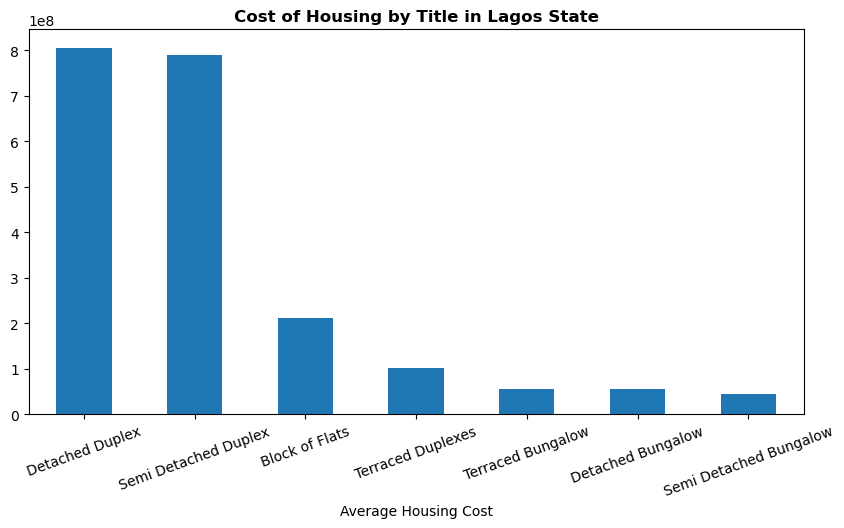

In [20]:
plt.figure(figsize=(10,5))
Lagos_df.groupby('title')['price'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Cost of Housing by Title in Lagos State', weight='bold')
plt.xlabel('Average Housing Cost')
plt.xticks(rotation=20)
plt.show()

<h2 style = "text-align:center; font-weight:bold;">Findings</h2>

- The housing are very expensive in Ikoyi, Ifako-Ijaiyi, Victorial Island and Apapa. The most expensive town is Ikoyi. The less expensive town are Eko-Atlantic city, Imota, Epe, Igeju and Ijede.
- The most expensive house are detached duplex and semi detached duplex. The less expensive house are detached bungalow and semi detached bungalow.

<h3 style = "text-align:center; font-size:20; color:#cceb34">Building a House Price Predictive Model

#### Checking for multicollinearity

               bedrooms  bathrooms   toilets  parking_space     price
bedrooms       1.000000   0.718552  0.686911       0.219344  0.035419
bathrooms      0.718552   1.000000  0.803973       0.224328  0.029052
toilets        0.686911   0.803973  1.000000       0.225133  0.020186
parking_space  0.219344   0.224328  0.225133       1.000000  0.025601
price          0.035419   0.029052  0.020186       0.025601  1.000000


<Axes: >

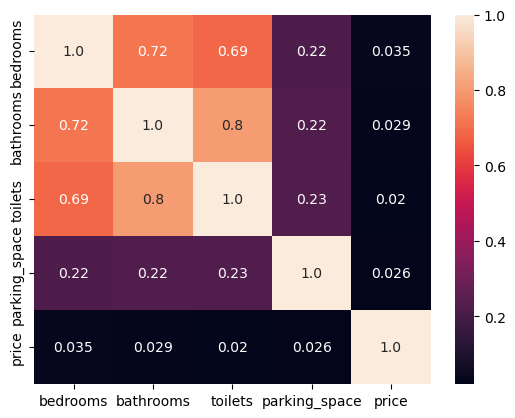

In [21]:
corr = Lagos_df.select_dtypes(include='number').corr()
print(corr)
sns.heatmap(corr, annot=True, fmt='.2')

There is a high correlation between bathroom and toilet, so I'm droping the toilet columns.

In [22]:
print('@@@@@@@@@@@@@@@@@@@'*10)

@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@


Building a function that we create a model for a specific state and town

In [29]:
def get_model(state = "Lagos", town = 'Lekki'):
# Sellecting the state
    state_df = df[df['state'] == state].drop('state', axis = 1)
    

# Sellecting the town
    town = state_df[state_df['town'] == town].drop('town', axis = 1)
    
# Dealing with outliers
    q1 = town['price'].quantile(0.25)
    q3 = town['price'].quantile(0.75)
    IQR = q3 - q1
    lower_bound = q1 - 3.0 * IQR
    upper_bound = q3 + 3.0 * IQR
    filt = (town['price'] <=lower_bound) & (town['price'] >=upper_bound)
    town = town[~filt]
    
    X = town.drop(columns = ['price', 'toilets'])
    y = town['price']
    
    # Splitting to X_train, X_test, y_train, y_test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    processor = ColumnTransformer(
    transformers= [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['title']),
                   ('scaler', StandardScaler(), ['bedrooms','bathrooms', 'parking_space'])],
    remainder='drop')
    
    # Assemblying the model
    pipe = Pipeline([
    ('precessor', processor),
    ('model', GradientBoostingRegressor(n_estimators=100))])
    
    # Train the model
    model = pipe.fit(X_train, y_train)
    
    # Testing the model
    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    #return f'rmse: {rmse:,.2f}'
    return X
    

get_model('Edo', 'Egor')

,bedrooms,bathrooms,parking_space,title
2468,3.0,3.0,4.0,Block of Flats
15796,4.0,2.0,4.0,Detached Bungalow
18213,4.0,5.0,4.0,Block of Flats
22887,3.0,5.0,4.0,Detached Bungalow


In [24]:
get_model('Lagos', 'Epe')


,bedrooms,bathrooms,toilets,parking_space,title,price
7,2.0,2.0,3.0,6.0,Detached Bungalow,12000000.0
66,2.0,2.0,3.0,1.0,Semi Detached Bungalow,12000000.0
475,2.0,2.0,3.0,1.0,Detached Bungalow,12000000.0
1819,2.0,5.0,3.0,3.0,Detached Bungalow,12000000.0
2679,2.0,5.0,5.0,4.0,Detached Bungalow,12000000.0
4627,2.0,2.0,3.0,3.0,Detached Bungalow,12000000.0
5127,2.0,3.0,3.0,2.0,Detached Bungalow,10000000.0
5192,2.0,2.0,2.0,4.0,Detached Bungalow,12000000.0
6338,4.0,5.0,5.0,4.0,Block of Flats,35000000.0
7462,2.0,2.0,3.0,4.0,Detached Bungalow,12000000.0


In [25]:
def get_town(state = 'Abuja'):
    town = df[df['state'] == state]['town'].str.strip().unique()
    return list(town)
get_town(state = "Lagos")

['Lekki',
 'Ajah',
 'Epe',
 'Victoria Island (VI)',
 'Ikeja',
 'Ikoyi',
 'Magodo',
 'Ibeju Lekki',
 'Yaba',
 'Ifako-Ijaiye',
 'Agege',
 'Ikorodu',
 'Isheri North',
 'Isheri',
 'Ipaja',
 'Mushin',
 'Ejigbo',
 'Isolo',
 'Ojodu',
 'Alimosho',
 'Shomolu',
 'Ogudu',
 'Surulere',
 'Ayobo',
 'Ikotun',
 'Maryland',
 'Gbagada',
 'Idimu',
 'Ojo',
 'Kosofe',
 'Ilupeju',
 'Ketu',
 'Ojota',
 'Oshodi',
 'Amuwo Odofin',
 'Ijede',
 'Agbara-Igbesa',
 'Ijaiye',
 'Apapa',
 'Lagos Island',
 'Badagry',
 'Oke-Odo',
 'Egbe',
 'Orile',
 'Eko Atlantic City',
 'Imota',
 'Ijesha',
 'Ibeju']

In [26]:
df

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,4.500000e+08
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,8.000000e+08
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,1.200000e+08
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,4.000000e+07
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,7.500000e+07
...,...,...,...,...,...,...,...,...
24319,8.0,8.0,9.0,4.0,Detached Duplex,Guzape District,Abuja,1.000000e+09
24320,3.0,4.0,4.0,5.0,Detached Duplex,Lekki,Lagos,8.000000e+07
24321,2.0,2.0,2.0,4.0,Block of Flats,Kabusa,Abuja,1.500000e+07
24322,4.0,5.0,5.0,4.0,Block of Flats,Ado-Odo/Ota,Ogun,2.500000e+07


In [27]:
df['town'].unique()

array(['Mabushi', 'Katampe', 'Lekki', 'Ajah', 'Epe', 'Lokogoma District',
       'Oredo', 'Victoria Island (VI)', 'Mowe Ofada', 'Ikeja', 'Ikoyi',
       'Magodo', 'Kaura', 'Galadimawa', 'Gwarinpa', 'Abeokuta North',
       'Lugbe District', 'Ibeju Lekki', 'Yaba', 'Sango Ota',
       'Ifako-Ijaiye', 'Agege', 'Ikorodu', 'Jahi', 'Ibadan', 'Orozo',
       'Ifo', 'Owerri North', 'Guzape District', 'Idu Industrial',
       'Owerri Municipal', 'Isheri North', 'Utako', 'Port Harcourt',
       'Kuje', 'Isheri', 'Life Camp', 'Ipaja', 'Ado-Odo/Ota', 'Dape',
       'Mushin', 'Ejigbo', 'Isolo', 'Ojodu', 'Gaduwa', 'Enugu', 'Dakwo',
       'Asokoro District', 'Alimosho', 'Sagamu', 'Chikun', 'Egbeda',
       'Wuye', 'Kubwa', 'Shomolu', 'Ogudu', 'Owerri West', 'Ibafo',
       'Surulere', 'Obio-Akpor', 'Ayobo', 'Apo', 'Mowe Town',
       'Ibadan South-West', 'Wuse 2', 'Durumi', 'Simawa', 'Arepo',
       'Ikotun', 'Oluyole', 'Maitama District', 'Maryland', 'Ido',
       'Karsana', 'Wuse', 'Kurudu', 'Karm